In [29]:
import casadi as ca
from environments.utils.funcionesEMS import*
from environments.utils.funcionesEMS import manage_batteries as manage_batteries2
from environments.Data.EMS.EMS_constants import *
import matplotlib.pyplot as plt
from scipy.special import exp1
import numpy as np
from environments.EMS_policies import PumpingPolicy

In [30]:
radiation = get_rad()
temperature = get_temperatura()

p_pv = solar_power(radiation, temperature)
p_d = get_demand()

In [31]:
def drawdown(k: int, dQ: Iterable):  # drawdown of the well
    """
    Computes the drawdown of the well according the theis equation
    :param k: time instant
    :param dQ: delta flow rate [m3/s]
    :return: drawdown
    """
    assert k == len(dQ), "The length of dQ should match the number of temporal k points"
    
    l = np.arange(1, k + 1)
    arg = (r_wells ** 2 * S) / (4 * T * (k - l + 1) * 600)
    sum_ = 0.0
    for i in range(k):
        sum_ += dQ[i] * exp1(arg[i])
    s_val = 1 / (4 * np.pi * T) * sum_
    return s_val

In [32]:
def manage_batteries(SoE: ca.SX,
                     P_fv: ca.SX,
                     P_demanded: ca.SX,
                     P_pump: ca.SX) -> tuple[ca.SX, ca.SX]:
    """
    Choose the power to re/discharge the batteries and computes the next SoE
    :param SoE: State of Energy of the battery [kWh]
    :param P_fv: power generated by the PV panels [kW]
    :param P_demanded: power demanded by the loads [kW]
    :param P_pumps: list with the power demanded by the pumps
    :returns: Pbat, next_SoE, E_residual
    """
    E_surplus = ca.SX(0.0)
    E_deficit = ca.SX(0.0)

    P_residual = P_fv - P_demanded - P_pump
    Pbat = ca.if_else(ca.fabs(P_residual) > Pbat_max, ca.fmin(ca.fmax(P_residual, -Pbat_max), Pbat_max), P_residual)
    P_not_used = P_residual - Pbat

    delta_SoE = ca.if_else(Pbat >= 0, Pbat * n_c * (dt / 3600), Pbat / n_d * (dt / 3600))
    next_SoE = SoE + delta_SoE

    E_surplus = ca.if_else(next_SoE > SoE_max, next_SoE - SoE_max, 0)
    E_deficit = ca.if_else(next_SoE < SoE_min, SoE_min - next_SoE, 0)

    next_SoE = ca.fmin(ca.fmax(next_SoE, SoE_min), SoE_max)
    #Pbat = ca.if_else(delta_SoE > 0, ca.fmax(SoE_max - SoE, 0) / (dt / 3600) / n_c, ca.fmin(SoE_min - SoE, 0) * n_d / (dt / 3600))
    Pbat = ca.if_else(next_SoE > SoE_max , ca.fmax(SoE_max - SoE, 0) / (dt / 3600) / n_c, Pbat)
    Pbat = ca.if_else(next_SoE < SoE_min , ca.fmin(SoE_min - SoE, 0) * n_d / (dt / 3600), Pbat)

    E_surplus += ca.if_else(P_not_used > 0, P_not_used * (dt / 3600), 0)
    E_deficit += ca.if_else(P_not_used < 0, -P_not_used / n_d * (dt / 3600), 0)

    E_residual = E_surplus + E_deficit

    return Pbat, E_residual


In [33]:
# Define the control horizon
N = 143 + 144  # Number of steps

# Define optimization variables
U = ca.SX.sym("U", 2, N)  # Control inputs
X = ca.SX.sym("X", 4, N + 1)  # States
K_p = 1.0
# Define the cost function and constraints
cost = 0


# Initial conditions
constraints = [(X[0,0] - 2.0),
               (X[1,0] - 0.0),
               (X[2,0] - 50.0),
               (X[3,0]- 1e-3)]  # Initial conditions for the states


for k in range(N):
    # Dynamics constraint
    constraints.append(X[0,k + 1] - (X[0, k] + (U[0, k]-U[1, k])*dt/1000))  # Vtanks
    constraints.append(X[1,k + 1] - (X[1, k] + U[1, k]*dt/1000))  # Virrs
    p_bat, e_res = manage_batteries(X[2, k], float(p_pv[k]), float(p_d[k]), K_p*U[0, k])
    constraints.append(X[2,k + 1] - (X[2, k] + p_bat*dt/3600))  # SoE
    dQs = [(U[0, i] - U[0, i-1])*1e-3 for i in range(k+1)] if k > 0 else [U[0, 0]*1e-3]
    constraints.append(X[3,k + 1] - (drawdown(k+1, dQs)))
    # Update 

    constraints.append(X[0,k+1])
    constraints.append(X[1,k+1])
    constraints.append(X[2,k+1])
    constraints.append(X[3,k+1])

    constraints.append(U[0,k])
    constraints.append(U[1,k])
    cost += -e_res

# Define bounds for constraints
lbg = [0,0,0,0]  # Equality constraint for initial condition
ubg = [0,0,0,0]

for k in range(N):
    # Equality constraints for dynamics
    lbg.extend([0, 0, 0, 0])  # Lower bounds for dynamics
    ubg.extend([0, 0, 0, 0])  # Upper bounds for dynamics

    lbg.extend([1, 0, 20, 0])  # Lower bounds 
    ubg.extend([5, ca.inf, 100, 1])  # Upper bounds 

    # Inequality constraint for U[0, k] >= 0
    lbg.extend([0, 0])  # Lower bound
    ubg.extend([1.0, 1.0])  # No upper bound

# Final condition (equality constraint)
lbg.append(0)
ubg.append(0)

constraints.append(X[1, N] - 5)  # Final condition (reference fulfillment)

# Combine decision variables into a single vector
decision_variables = ca.vertcat(ca.reshape(X, -1, 1), ca.reshape(U, -1, 1))
# Create the NLP problem
nlp_control = {
    'x': ca.vertcat(ca.reshape(X, -1, 1), ca.reshape(U, -1, 1)),
    'f': cost,             # Objective function
    'g': ca.vertcat(*constraints)  # Constraints
}

# Create the solver
solver_control = ca.nlpsol('solver_control', 'ipopt', nlp_control)
#

In [18]:
solution_control = solver_control(
    x0=np.zeros((4 * (N + 1) + 2 * N,)),  # Initial guess
    lbg=lbg,  # Lower bound on constraints
    ubg=ubg   # Upper bound on constraints
)

This is Ipopt version 3.14.11, running with linear solver MUMPS 5.4.1.

Number of nonzeros in equality constraint Jacobian...:    44775
Number of nonzeros in inequality constraint Jacobian.:     1722
Number of nonzeros in Lagrangian Hessian.............:      861

Total number of variables............................:     1726
                     variables with only lower bounds:        0
                variables with lower and upper bounds:        0
                     variables with only upper bounds:        0
Total number of equality constraints.................:     1153
Total number of inequality constraints...............:     1722
        inequality constraints with only lower bounds:      287
   inequality constraints with lower and upper bounds:     1435
        inequality constraints with only upper bounds:        0

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
   0 -6.1324182e+03 5.00e+01 5.87e-01  -1.0 0.00e+00    -  0.00e+00 0.00e+00 

In [19]:
# Extract the solution for decision variables
solution_values = solution_control['x']

# Extract the cost value
solution_cost = solution_control['f']

# Extract the constraint values
solution_constraints = solution_control['g']

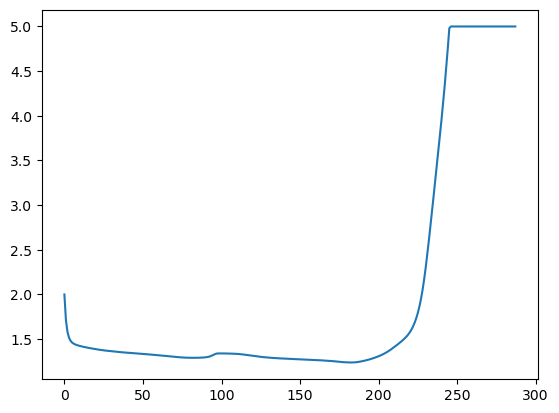

In [40]:
states = np.array(ca.reshape(solution_values[:4 * (N + 1)], (4, N + 1)))

plt.plot(states[0], label="x1")


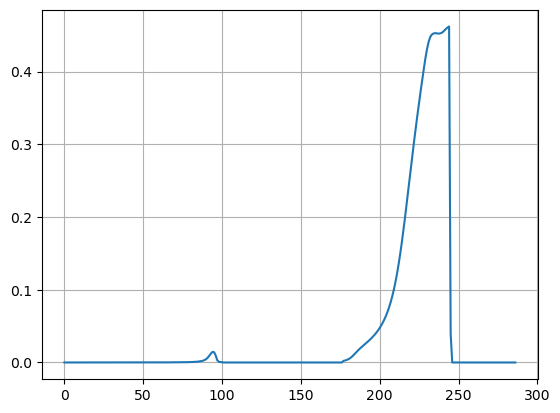

In [39]:
actions = np.array(ca.reshape(solution_values[4 * (N + 1):], (2, N)))
plt.plot(actions[0], label="u1")
plt.grid()

In [10]:
dQS = np.array([1 if k == 0 else -1 if k==1 else 0 for k in range(N)])
dQS = np.concatenate(([actions[0,0]], np.diff(actions[0])))
drawdown_values = [drawdown(k+1, dQS[:k+1]*1e-3) for k in range(N)]

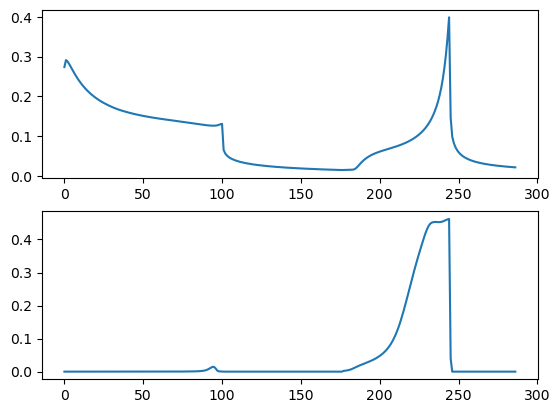

In [22]:
fig, ax = plt.subplots(2,1)
ax[0].plot(drawdown_values, label="drawdown")
ax[1].plot(actions[0])


In [38]:
pbats = []
e_res = []
for i in range(len(states[2])-1):
    pbat, _, e_res_ = manage_batteries2(states[2,i], float(p_pv[i]), float(p_d[i]), [K_p*actions[0, i]])
    pbats.append(float(pbat))
    e_res.append(float(e_res_))


In [13]:
len(actions[0])

287

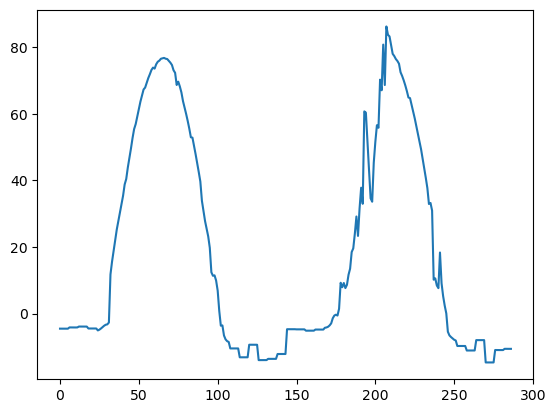

In [35]:
plt.plot(pbats)

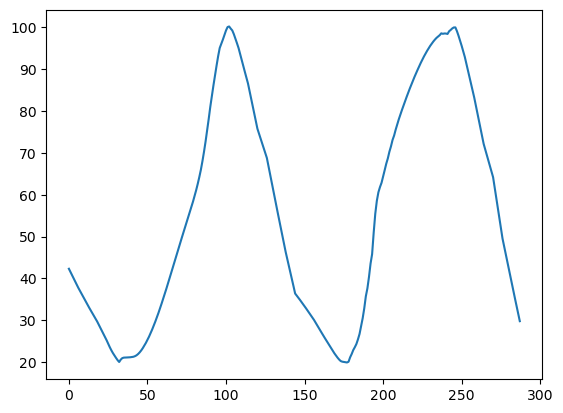

In [25]:
plt.plot(states[2], label="SoE")

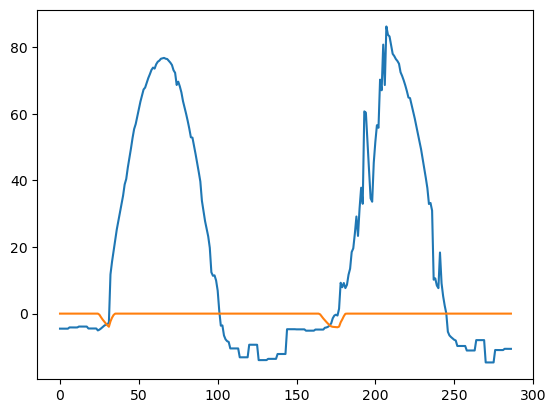

In [36]:
plt.plot(pbats)
plt.plot(e_res)

In [37]:
pbats

[-4.5146904522733395,
 -4.5167844392837955,
 -4.514311563765601,
 -4.51697715485194,
 -4.520310267948673,
 -4.519982418508062,
 -4.146254608781122,
 -4.152445552535308,
 -4.151688738871952,
 -4.146774623060076,
 -4.158546166026441,
 -4.141152316551536,
 -3.884788605567344,
 -3.8863832873116206,
 -3.8884896258273343,
 -3.8899713373927205,
 -3.885513243252005,
 -3.893434053942316,
 -4.46733017287533,
 -4.468866914432749,
 -4.469173371466576,
 -4.469601707805894,
 -4.468738576262369,
 -4.4679384917045155,
 -5.047610296292464,
 -4.813515776526771,
 -4.460296149736614,
 -4.034946846232396,
 -3.6375424633081326,
 -3.3390628320670634,
 -3.225748993495257,
 -2.6774876247580788,
 11.763936356447765,
 15.624798697074892,
 18.813017694520127,
 21.9826844240713,
 25.2686601046917,
 27.829924798525568,
 30.236132528353263,
 33.1105570551525,
 35.425527404970694,
 38.788936628412564,
 40.44771838003249,
 43.866088334326534,
 46.72241436227952,
 49.599907277934044,
 52.72505741688184,
 55.42676129559